In [30]:
import snowflake.connector
print("snowflake installed successfully")

snowflake installed successfully


In [31]:
import pandas as pd
from snowflake.connector.pandas_tools import write_pandas
import snowflake.connector

In [ ]:
# Snowflake connection details
conn = snowflake.connector.connect(
    user='*******',
    password='****',
    account='******',
    warehouse='compute_wh',
    database='JHANSI_STORE',
    schema='JHANSI_STORE'
)

In [122]:
Marketing_data=pd.read_csv("C:/python_proj/Marketing_conversion.csv")

In [59]:
Marketing_data.head()


,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion
0,708746,916,103916,30-34,M,15,7350,1,1.43,2.0,1
1,708749,916,103917,30-34,M,16,17861,2,1.82,2.0,0
2,708771,916,103920,30-34,M,20,693,0,0.00,1.0,0
3,708815,916,103928,30-34,M,28,4259,1,1.25,1.0,0
4,708818,916,103928,30-34,M,28,4133,1,1.29,1.0,1


In [60]:
Marketing_data.columns

Index(['ad_id', 'xyz_campaign_id', 'fb_campaign_id', 'age', 'gender',
       'interest', 'Impressions', 'Clicks', 'Spent', 'Total_Conversion',
       'Approved_Conversion'],
      dtype='object')

In [123]:
Marketing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ad_id                1143 non-null   int64  
 1   xyz_campaign_id      1143 non-null   int64  
 2   fb_campaign_id       1143 non-null   int64  
 3   age                  1143 non-null   object 
 4   gender               1143 non-null   object 
 5   interest             1143 non-null   int64  
 6   Impressions          1143 non-null   object 
 7   Clicks               1143 non-null   int64  
 8   Spent                1142 non-null   float64
 9   Total_Conversion     1137 non-null   float64
 10  Approved_Conversion  1142 non-null   object 
dtypes: float64(2), int64(5), object(4)
memory usage: 98.4+ KB


In [63]:
#lets understand datatypes

Marketing_data.dtypes

ad_id                    int64
xyz_campaign_id          int64
fb_campaign_id           int64
age                     object
gender                  object
interest                 int64
Impressions             object
Clicks                   int64
Spent                  float64
Total_Conversion       float64
Approved_Conversion     object
dtype: object

In [124]:
#Check missing values
 

Marketing_data.isnull().sum()


ad_id                  0
xyz_campaign_id        0
fb_campaign_id         0
age                    0
gender                 0
interest               0
Impressions            0
Clicks                 0
Spent                  1
Total_Conversion       6
Approved_Conversion    1
dtype: int64

In [125]:
Marketing_data['Approved_Conversion'].value_counts()

Approved_Conversion
0     558
1     402
2      86
3      35
4      24
6       7
5       7
8       5
10      4
7       4
9       3
14      2
12      1
17      1
21      1
&       1
13      1
Name: count, dtype: int64

In [126]:
(Marketing_data['Approved_Conversion']=='&').sum()

np.int64(1)

In [127]:
'''  When a column has special characters (like "&"),
DO NOT directly replace with mean/median..first convert to numeric,
that will convert them as nan(Invalid values ("&", "abc") → become NaN)'''

Marketing_data['Approved_Conversion']=pd.to_numeric(Marketing_data['Approved_Conversion'],errors='coerce')

In [130]:
Marketing_data['Approved_Conversion'].isnull().sum()

np.int64(2)

In [131]:
Marketing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ad_id                1143 non-null   int64  
 1   xyz_campaign_id      1143 non-null   int64  
 2   fb_campaign_id       1143 non-null   int64  
 3   age                  1143 non-null   object 
 4   gender               1143 non-null   object 
 5   interest             1143 non-null   int64  
 6   Impressions          1143 non-null   object 
 7   Clicks               1143 non-null   int64  
 8   Spent                1142 non-null   float64
 9   Total_Conversion     1137 non-null   float64
 10  Approved_Conversion  1141 non-null   float64
dtypes: float64(3), int64(5), object(3)
memory usage: 98.4+ KB


In [132]:
Marketing_data.select_dtypes(include='number').columns

Index(['ad_id', 'xyz_campaign_id', 'fb_campaign_id', 'interest', 'Clicks',
       'Spent', 'Total_Conversion', 'Approved_Conversion'],
      dtype='object')

In [133]:
Marketing_data.select_dtypes(include='number')

,ad_id,xyz_campaign_id,fb_campaign_id,interest,Clicks,Spent,Total_Conversion,Approved_Conversion
0,708746,916,103916,15,1,1.430000,2.0,1.0
1,708749,916,103917,16,2,1.820000,2.0,0.0
2,708771,916,103920,20,0,0.000000,1.0,0.0
3,708815,916,103928,28,1,1.250000,1.0,0.0
4,708818,916,103928,28,1,1.290000,1.0,1.0
...,...,...,...,...,...,...,...,...
1138,1314410,1178,179977,109,252,358.189997,13.0,2.0
1139,1314411,1178,179978,110,120,173.880003,3.0,0.0
1140,1314412,1178,179979,111,28,40.289999,2.0,0.0
1141,1314414,1178,179981,113,135,198.710001,8.0,2.0


In [134]:
numeric_cols=Marketing_data.select_dtypes(include='number').columns

In [135]:
numeric_cols=numeric_cols.drop(['ad_id','xyz_campaign_id','fb_campaign_id'])

In [136]:
Marketing_data[numeric_cols].describe()

,interest,Clicks,Spent,Total_Conversion,Approved_Conversion
count,1143.000000,1143.000000,1142.000000,1137.000000,1141.000000
mean,32.766404,33.390201,51.375473,2.864556,0.944785
std,26.952131,56.892438,86.945050,4.493652,1.739006
min,2.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,1.000000,1.480000,1.000000,0.000000
50%,25.000000,8.000000,12.260000,1.000000,1.000000
75%,31.000000,37.500000,60.112500,3.000000,1.000000
max,114.000000,421.000000,639.949998,60.000000,21.000000


In [87]:
numeric_cols

Index(['interest', 'Clicks', 'Spent', 'Total_Conversion'], dtype='object')

In [137]:
#check outlier for all numeric columns
 

   
    
    
for col in numeric_cols:
      Q1=Marketing_data[col].quantile(0.25)
      Q3=Marketing_data[col].quantile(0.75)
      IQR = Q3 - Q1
      lower = Q1 - 1.5 * IQR
      upper = Q3 + 1.5 * IQR
      outliers = Marketing_data[(Marketing_data[col] < lower) | 
                              (Marketing_data[col] > upper)]
      
      print(col, ":", len(outliers))
      #print(col, ":", outliers)
  
   

interest : 219
Clicks : 127
Spent : 125
Total_Conversion : 105
Approved_Conversion : 95


In [ ]:
'''Remove outliers (not always recommended here) outliers values r high
   Risk: You may lose important high-performing ads'''

[True]


In [138]:
#lets fill median value for null values instead mean...as mean is affected by these outliers...

Marketing_data[numeric_cols]=Marketing_data[numeric_cols].fillna(Marketing_data[numeric_cols].median())

In [104]:
Marketing_data['Clicks'].median()

8.0

In [139]:
Marketing_data[numeric_cols].isnull().sum()

interest               0
Clicks                 0
Spent                  0
Total_Conversion       0
Approved_Conversion    0
dtype: int64

In [140]:
Marketing_data[numeric_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   interest             1143 non-null   int64  
 1   Clicks               1143 non-null   int64  
 2   Spent                1143 non-null   float64
 3   Total_Conversion     1143 non-null   float64
 4   Approved_Conversion  1143 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 44.8 KB


In [141]:
Marketing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ad_id                1143 non-null   int64  
 1   xyz_campaign_id      1143 non-null   int64  
 2   fb_campaign_id       1143 non-null   int64  
 3   age                  1143 non-null   object 
 4   gender               1143 non-null   object 
 5   interest             1143 non-null   int64  
 6   Impressions          1143 non-null   object 
 7   Clicks               1143 non-null   int64  
 8   Spent                1143 non-null   float64
 9   Total_Conversion     1143 non-null   float64
 10  Approved_Conversion  1143 non-null   float64
dtypes: float64(3), int64(5), object(3)
memory usage: 98.4+ KB


In [142]:
Marketing_data['Impressions'].value_counts()

Impressions
2479      2
3812      2
152       2
1539      2
1772      2
         ..
9134      1
3385      1
1314      1
2916      1
513161    1
Name: count, Length: 1130, dtype: int64

In [144]:
Marketing_data['Impressions'].unique()

array(['7350', '17861', '693', ..., '151531', '790253', '513161'],
      shape=(1130,), dtype=object)

In [146]:
Marketing_data['Impressions']=pd.to_numeric(Marketing_data['Impressions'], errors='coerce')

In [147]:
Marketing_data['Impressions'].unique()

array([7.35000e+03, 1.78610e+04, 6.93000e+02, ..., 1.51531e+05,
       7.90253e+05, 5.13161e+05], shape=(1128,))

In [148]:
Marketing_data['Impressions'].isnull().sum()

np.int64(3)

In [150]:
Marketing_data['Impressions'].value_counts(dropna=False)

Impressions
NaN         3
2479.0      2
2879.0      2
1539.0      2
152.0       2
           ..
1314.0      1
2916.0      1
6142.0      1
1984.0      1
513161.0    1
Name: count, Length: 1128, dtype: int64

In [151]:
Marketing_data['Impressions']=Marketing_data['Impressions'].fillna(Marketing_data['Impressions'].median())

In [153]:
Marketing_data['Impressions'].isnull().sum()

np.int64(0)

In [154]:
Marketing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ad_id                1143 non-null   int64  
 1   xyz_campaign_id      1143 non-null   int64  
 2   fb_campaign_id       1143 non-null   int64  
 3   age                  1143 non-null   object 
 4   gender               1143 non-null   object 
 5   interest             1143 non-null   int64  
 6   Impressions          1143 non-null   float64
 7   Clicks               1143 non-null   int64  
 8   Spent                1143 non-null   float64
 9   Total_Conversion     1143 non-null   float64
 10  Approved_Conversion  1143 non-null   float64
dtypes: float64(4), int64(5), object(2)
memory usage: 98.4+ KB


In [156]:
Marketing_data['age'].unique()

array(['30-34', '35-39', '40-44', '45-49'], dtype=object)

In [157]:
Marketing_data['age'].value_counts()

age
30-34    426
45-49    259
35-39    248
40-44    210
Name: count, dtype: int64

In [158]:
Marketing_data['gender'].unique()

array(['M', 'F'], dtype=object)

In [ ]:
''' Convert categorical (text) columns into numeric 0/1 columns

This is called One-Hot Encoding'''

pd.get_dummies(Marketing_data['gender'])

,F,M
0,False,True
1,False,True
2,False,True
3,False,True
4,False,True
...,...,...
1138,True,False
1139,True,False
1140,True,False
1141,True,False


In [ ]:
'''Before:
gender
M
F
M
After get_dummies():
gender_F   gender_M
0          1
1          0
0          1      
#dropping first column to avoid duplicates
because:

If we keep both:

gender_F + gender_M

We get redundant info:

gender_F	gender_M
1	0
0	1

 If one is 0, other is automatically 1
 So one column is enough
'''

In [ ]:
#dropping first column to avoid duplicates
pd.get_dummies(Marketing_data['gender'],drop_first=True)

,M
0,True
1,True
2,True
3,True
4,True
...,...
1138,False
1139,False
1140,False
1141,False


In [163]:
pd.get_dummies(Marketing_data, columns=['gender'], drop_first=True)

,ad_id,xyz_campaign_id,fb_campaign_id,age,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion,gender_M
0,708746,916,103916,30-34,15,7350.0,1,1.430000,2.0,1.0,True
1,708749,916,103917,30-34,16,17861.0,2,1.820000,2.0,0.0,True
2,708771,916,103920,30-34,20,693.0,0,0.000000,1.0,0.0,True
3,708815,916,103928,30-34,28,4259.0,1,1.250000,1.0,0.0,True
4,708818,916,103928,30-34,28,4133.0,1,1.290000,1.0,1.0,True
...,...,...,...,...,...,...,...,...,...,...,...
1138,1314410,1178,179977,45-49,109,1129773.0,252,358.189997,13.0,2.0,False
1139,1314411,1178,179978,45-49,110,637549.0,120,173.880003,3.0,0.0,False
1140,1314412,1178,179979,45-49,111,151531.0,28,40.289999,2.0,0.0,False
1141,1314414,1178,179981,45-49,113,790253.0,135,198.710001,8.0,2.0,False


In [164]:
Marketing_data= pd.get_dummies(Marketing_data, columns=['gender'], drop_first=True)

In [165]:
Marketing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ad_id                1143 non-null   int64  
 1   xyz_campaign_id      1143 non-null   int64  
 2   fb_campaign_id       1143 non-null   int64  
 3   age                  1143 non-null   object 
 4   interest             1143 non-null   int64  
 5   Impressions          1143 non-null   float64
 6   Clicks               1143 non-null   int64  
 7   Spent                1143 non-null   float64
 8   Total_Conversion     1143 non-null   float64
 9   Approved_Conversion  1143 non-null   float64
 10  gender_M             1143 non-null   bool   
dtypes: bool(1), float64(4), int64(5), object(1)
memory usage: 90.5+ KB


In [166]:
Marketing_data['gender_M'] = Marketing_data['gender_M'].astype(int)

In [167]:
Marketing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ad_id                1143 non-null   int64  
 1   xyz_campaign_id      1143 non-null   int64  
 2   fb_campaign_id       1143 non-null   int64  
 3   age                  1143 non-null   object 
 4   interest             1143 non-null   int64  
 5   Impressions          1143 non-null   float64
 6   Clicks               1143 non-null   int64  
 7   Spent                1143 non-null   float64
 8   Total_Conversion     1143 non-null   float64
 9   Approved_Conversion  1143 non-null   float64
 10  gender_M             1143 non-null   int64  
dtypes: float64(4), int64(6), object(1)
memory usage: 98.4+ KB


In [169]:
#array(['30-34', '35-39', '40-44', '45-49']

age_map = {'30-34': 1, 
           '35-39': 2, 
           '40-44': 3, 
           '45-49': 4 
           }

In [170]:
Marketing_data['age'] = Marketing_data['age'].map(age_map)

In [171]:
Marketing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ad_id                1143 non-null   int64  
 1   xyz_campaign_id      1143 non-null   int64  
 2   fb_campaign_id       1143 non-null   int64  
 3   age                  1143 non-null   int64  
 4   interest             1143 non-null   int64  
 5   Impressions          1143 non-null   float64
 6   Clicks               1143 non-null   int64  
 7   Spent                1143 non-null   float64
 8   Total_Conversion     1143 non-null   float64
 9   Approved_Conversion  1143 non-null   float64
 10  gender_M             1143 non-null   int64  
dtypes: float64(4), int64(7)
memory usage: 98.4 KB


In [172]:
Marketing_data.head()

,ad_id,xyz_campaign_id,fb_campaign_id,age,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion,gender_M
0,708746,916,103916,1,15,7350.0,1,1.43,2.0,1.0,1
1,708749,916,103917,1,16,17861.0,2,1.82,2.0,0.0,1
2,708771,916,103920,1,20,693.0,0,0.00,1.0,0.0,1
3,708815,916,103928,1,28,4259.0,1,1.25,1.0,0.0,1
4,708818,916,103928,1,28,4133.0,1,1.29,1.0,1.0,1


In [173]:
type(Marketing_data)

pandas.core.frame.DataFrame

In [182]:
Marketing_data.columns = Marketing_data.columns.str.upper()

In [ ]:
create_table_query = """
CREATE OR REPLACE TABLE MARKETING_DATA (
    ad_id INTEGER,
    xyz_campaign_id INTEGER,
    fb_campaign_id INTEGER,
    age INTEGER,
    interest  INTEGER, 
    Impressions FLOAT, 
    Clicks INTEGER, 
    Spent FLOAT,
    Total_Conversion FLOAT, 
    Approved_Conversion FLOAT, 
    gender_M INTEGER
    
)
"""
cursor = conn.cursor()
cursor.execute(create_table_query)
cursor.close()

True

In [183]:
success, nchunks, nrows, _ = write_pandas(conn, Marketing_data, 'MARKETING_DATA', chunk_size = 200)

print(f"Success: {success}, Number of chunks: {nchunks}, Number of rows: {nrows}")

conn.close()

Success: True, Number of chunks: 6, Number of rows: 1143


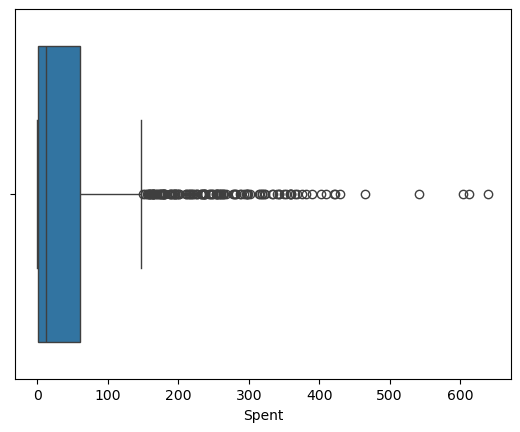

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=Marketing_data['Spent'])
plt.show()

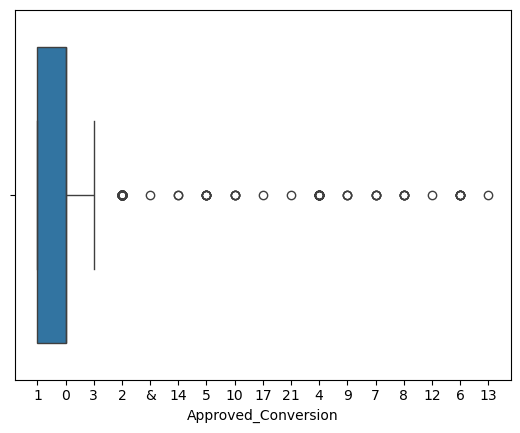

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=Marketing_data['Approved_Conversion'])
plt.show()

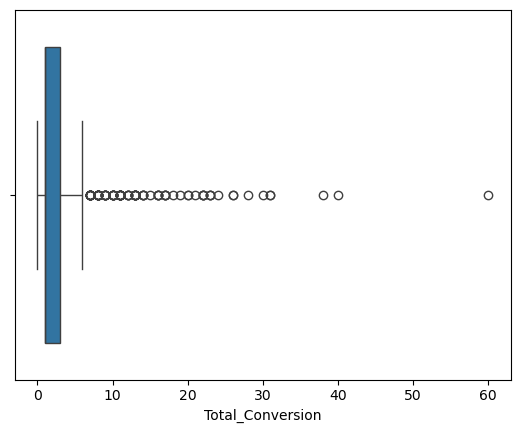

In [55]:

import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=Marketing_data['Total_Conversion'])
plt.show()

In [56]:
Marketing_data['Spent'].describe()

count    1143.000000
mean       51.375473
std        86.906974
min         0.000000
25%         1.480000
50%        12.370000
75%        60.025000
max       639.949998
Name: Spent, dtype: float64

In [57]:
Marketing_data['Spent'].skew()

np.float64(2.7084961268347163)

In [ ]:
"""
Skew value    	 Meaning
~0	              normal → mean
> 1 or < -1	     skewed → median 
"""